# 02 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

%run "./01_etl_pipeline.ipynb" #para sacar las variables del notebook 01_etl_pipeline.ipynb

usuario = 'postgres'
password = 'Ab123456*'
host = 'localhost'
puerto = '5432'
bd = 'suicidios_colombia'

engine = create_engine(f'postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{bd}')

### 1. Análisis temporal de la tendencia historia (2015 - 2024)

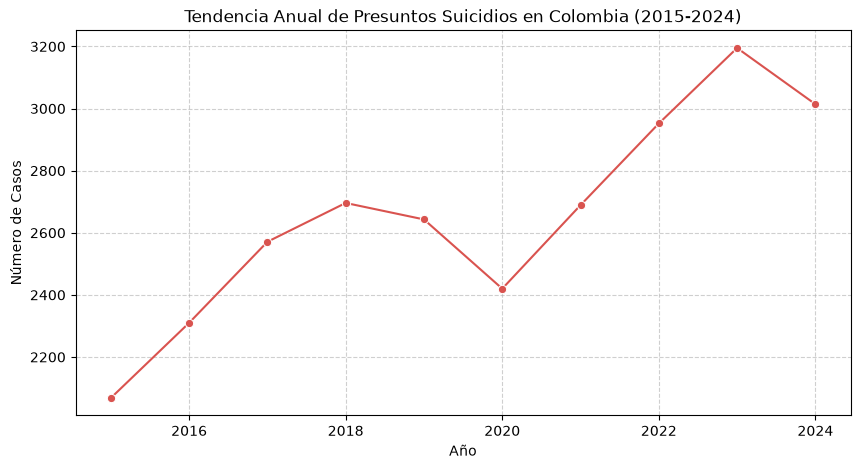

In [4]:
query_temporal = """
    SELECT 
        dt.anio, 
        SUM(f.cantidad) as total_casos
    FROM fact_presuntos_suicidios f
    JOIN dim_tiempo dt ON f.id_tiempo = dt.id_tiempo
    GROUP BY dt.anio
    ORDER BY dt.anio;
"""
df_tendencia = pd.read_sql(query_temporal, engine)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_tendencia, x='anio', y='total_casos', marker='o', color='#d9534f')
plt.title('Tendencia Anual de Presuntos Suicidios en Colombia (2015-2024)')
plt.xlabel('Año')
plt.ylabel('Número de Casos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 2. Perfil demográfico de vulvenrabilidad (edad y sexo)

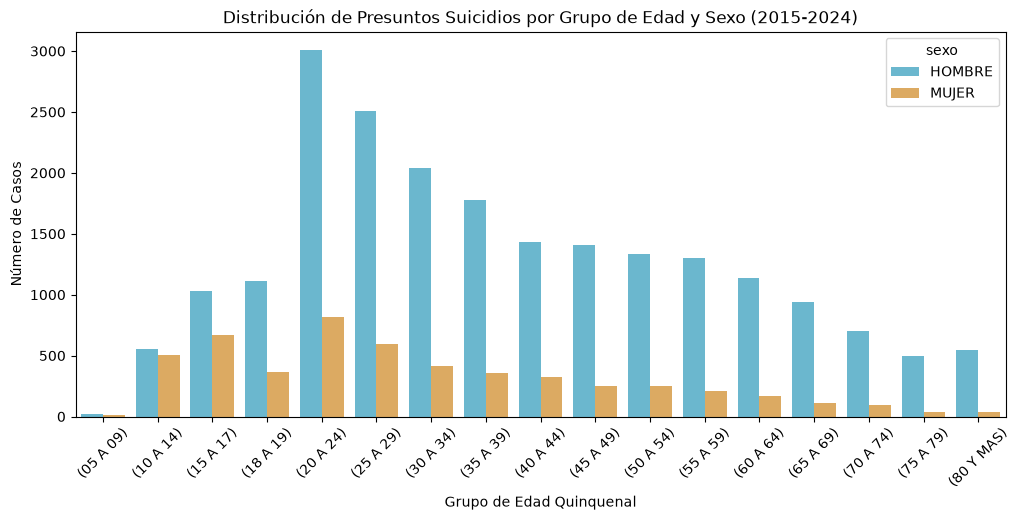

In [10]:
query_demografia = """
    SELECT
        dv.grupo_edad_quinquenal,
        dv.sexo,
        SUM(f.cantidad) as total_casos
    FROM fact_presuntos_suicidios f
    JOIN dim_victima dv ON f.id_victima = dv.id_victima
    WHERE dv.grupo_edad_quinquenal != 'SIN DATO'
    GROUP BY dv.grupo_edad_quinquenal, dv.sexo
    ORDER BY dv.grupo_edad_quinquenal ASC;
"""

df_demografia = pd.read_sql(query_demografia, engine)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_demografia,
    x='grupo_edad_quinquenal',
    y='total_casos',
    hue='sexo',
    palette={'HOMBRE': '#5bc0de', 'MUJER': '#f0ad4e'}
)
plt.title('Distribución de Presuntos Suicidios por Grupo de Edad y Sexo (2015-2024)')
plt.xlabel('Grupo de Edad Quinquenal')
plt.xticks(rotation=45)
plt.ylabel('Número de Casos')
plt.show()

### 3. Análisis geográfico local

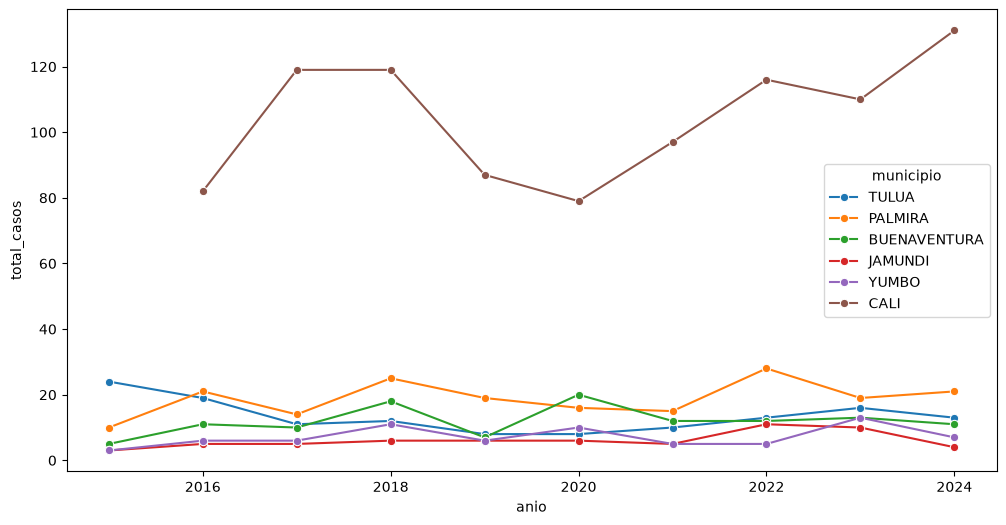

In [ ]:
query_geografia = """ 
    SELECT 
        dg.municipio,
        dt.anio,
        SUM(f.cantidad) as total_casos
    FROM fact_presuntos_suicidios f
    JOIN dim_geografia dg ON f.id_geografia = dg.id_geografia
    JOIN dim_tiempo dt ON f.id_tiempo = dt.id_tiempo
    WHERE dg.departamento = 'VALLE DEL CAUCA' AND dg.municipio IN ('CALI', 'BUENAVENTURA', 'YUMBO', 'TULUA', 'PALMIRA', 'JAMUNDI')
    GROUP BY dg.municipio, dt.anio
    ORDER BY dt.anio, total_casos DESC;
"""

df_valle = pd.read_sql(query_geografia, engine)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_valle,
    x='anio',
    y='total_casos',
    hue='municipio',
    marker='o'
)
plt.title('Tendencia de Presuntos Suicidios en Municipios del Valle del Cauca (2015-2024)')
plt.xlabel('Año')
plt.ylabel('Total de Casos')
plt.show()